# 02 — DistilBERT fine-tuning

**Owner:** Van (Modeler)  
**MLflow experiment:** `sentiment-distilbert`  
**Data:** `data/local/gold/gold_50k_training.csv` (gitignored; built by the gold EDA notebook)

Offline experimentation notebook — fine-tunes DistilBERT and compares it against the
sklearn baseline from `01_tfidf_logreg_tuning.ipynb`. Best model is registered as
`sentiment-distilbert` in the MLflow Registry.

Experiments: A baseline fine-tune → B weighted loss → C weighted loss + neutral oversample →
threshold tuning → final eval on test + OOT → register → (optional) LR sensitivity probes.

> **Dependencies:** `pip install datasets` if missing (transformers, torch are in `models/requirements.txt`).
>
> **Hardware warning:** this venv has CPU-only torch. 4 epochs × ~34K rows on CPU will take
> many hours. Strongly consider a GPU runtime (e.g. Colab — upload the CSV) or, for a quick
> wiring check, subsample `train_df` / set `EPOCHS = 1` first.

In [1]:
import torch
print(torch.cuda.is_available())       # True
print(torch.cuda.get_device_name(0))   # NVIDIA GeForce RTX 5080 Laptop GPU


True
NVIDIA GeForce RTX 5080 Laptop GPU


## [0] Imports and config

In [ ]:
# import subprocess, sys

# # pyarrow on Windows can have broken DLL linkage after a partial install.
# # Force-reinstall it first so datasets can import _dataset successfully.
# subprocess.check_call([
#     sys.executable, "-m", "pip", "install", "-q",
#     "--force-reinstall", "--no-cache-dir", "pyarrow"
# ])

# _HEAVY_DEPS = ["datasets", "accelerate"]
# _missing = []
# for _pkg in _HEAVY_DEPS:
#     try:
#         __import__(_pkg)
#     except ImportError:
#         _missing.append(_pkg)

# if _missing:
#     print(f"Installing missing deps: {_missing}")
#     subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + _missing)

# print("All deps ready — restart the kernel now if pyarrow was just reinstalled.")

: 

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

# Resolve repo root whether the kernel cwd is repo root or notebooks/
ROOT = Path.cwd()
if not (ROOT / "data" / "local").exists() and (ROOT.parent / "data" / "local").exists():
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "local" / "gold" / "gold_50k_training.csv"
ARTIFACT_DIR = ROOT / "models" / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

LABELS = ["negative", "neutral", "positive"]
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for l, i in LABEL2ID.items()}
NEG_IDX = 0  # index of "negative" in LABELS

MODEL_CHECKPOINT = "distilbert-base-uncased"
MAX_LENGTH = 256    # sufficient for restaurant reviews; saves memory vs 512
BATCH_TRAIN = 16    # reduce to 8 if running on CPU
BATCH_EVAL = 32
EPOCHS = 4
LR = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
OUTPUT_DIR = str(ROOT / "checkpoints" / "distilbert-sentiment")
SEED = 42

USE_GPU = torch.cuda.is_available()
print(f"Repo root: {ROOT}")
print(f"Data file exists: {DATA_PATH.exists()}")
print(f"GPU available: {USE_GPU}")

Repo root: c:\SMU_MITB\MLE\CS611_MLE\social_listener_project\Machine-Learning-Engineering-Group-9-Social-Listener
Data file exists: True
GPU available: True


In [2]:
# MLflow: local Docker server first (host port 5001), file-store fallback.
# docker-compose maps host 5001 -> container 5000 (5000 is often taken on macOS).
import os
import requests

TRACKING_URI = "http://localhost:5001"
try:
    requests.get(TRACKING_URI, timeout=2)
    mlflow.set_tracking_uri(TRACKING_URI)
    # Docker is up — remap MinIO endpoint to localhost so host-side boto3 can reach it.
    os.environ["MLFLOW_S3_ENDPOINT_URL"] = "http://localhost:9000"
except requests.exceptions.RequestException:
    mlflow.set_tracking_uri(f"file:{(ROOT / 'mlruns').as_posix()}")
    # Docker is down — clear S3 vars so artifacts stay on local filesystem, not MinIO.
    os.environ.pop("MLFLOW_S3_ENDPOINT_URL", None)
    os.environ.pop("AWS_ACCESS_KEY_ID", None)
    os.environ.pop("AWS_SECRET_ACCESS_KEY", None)

mlflow.set_experiment("sentiment-distilbert")
print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")

MLflow tracking URI: http://localhost:5001


## [1] Data loading and splits

Identical shared split code to `01_tfidf_logreg_tuning.ipynb` — temporal OOT/demo cutoffs,
then random stratified 80/10/10 from the remaining pool. Demo CSVs are written by
notebook 01; the writes here are idempotent (same seeds, same output).

> Cutoffs adjusted to this export's actual range (2021-05-02 → 2022-04-10):
> rest 85.7% / OOT 10.2% / demo 4.1%.

In [3]:
df = pd.read_csv(DATA_PATH, parse_dates=["review_date"])
df = df.sort_values("review_date").reset_index(drop=True)

# ── Temporal holdouts ──────────────────────────────────────────────────────────
OOT_CUTOFF = "2021-12-11"
DEMO_CUTOFF = "2022-01-09"

demo_df = df[df.review_date >= DEMO_CUTOFF].copy()
oot_df = df[(df.review_date >= OOT_CUTOFF) & (df.review_date < DEMO_CUTOFF)].copy()
rest_df = df[df.review_date < OOT_CUTOFF].copy()

# ── Random splits from rest_df ─────────────────────────────────────────────────
rest_df = rest_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

train_df, temp_df = train_test_split(
    rest_df, test_size=0.2, stratify=rest_df["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED
)

# ── Sanity check ───────────────────────────────────────────────────────────────
for name, split in [("train", train_df), ("val", val_df), ("test", test_df),
                    ("oot", oot_df), ("demo", demo_df)]:
    dist = split.label.value_counts(normalize=True).round(3).to_dict()
    print(f"{name:6s}  n={len(split):>6,}  {dist}")

y_train = train_df["label"].map(LABEL2ID).values
y_val = val_df["label"].map(LABEL2ID).values
y_test = test_df["label"].map(LABEL2ID).values
y_oot = oot_df["label"].map(LABEL2ID).values

train   n=34,413  {'positive': 0.716, 'negative': 0.212, 'neutral': 0.072}
val     n= 4,302  {'positive': 0.716, 'negative': 0.212, 'neutral': 0.072}
test    n= 4,302  {'positive': 0.716, 'negative': 0.212, 'neutral': 0.072}
oot     n= 5,147  {'positive': 0.704, 'negative': 0.217, 'neutral': 0.079}
demo    n= 2,056  {'positive': 0.739, 'negative': 0.198, 'neutral': 0.063}


In [4]:
def evaluate(y_true, y_pred, split_name: str, log_to_mlflow: bool = True) -> dict:
    """Compute and optionally log all metrics for a given split."""
    metrics = {
        f"{split_name}_f1_negative":        f1_score(y_true, y_pred, labels=[NEG_IDX], average="macro"),
        f"{split_name}_recall_negative":    recall_score(y_true, y_pred, labels=[NEG_IDX], average="macro"),
        f"{split_name}_precision_negative": precision_score(y_true, y_pred, labels=[NEG_IDX], average="macro"),
        f"{split_name}_f1_macro":           f1_score(y_true, y_pred, average="macro"),
        f"{split_name}_f1_neutral":         f1_score(y_true, y_pred, labels=[1], average="macro"),
        f"{split_name}_f1_positive":        f1_score(y_true, y_pred, labels=[2], average="macro"),
    }
    print(f"\n── {split_name.upper()} ──")
    print(classification_report(y_true, y_pred, target_names=LABELS))
    if log_to_mlflow:
        mlflow.log_metrics(metrics)
    return metrics

## [2] Tokenization

In [5]:
from datasets import Dataset
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)


def encode_df(frame: pd.DataFrame) -> Dataset:
    ds = Dataset.from_pandas(
        frame[["text", "label"]].assign(label=frame["label"].map(LABEL2ID)),
        preserve_index=False,
    )
    ds = ds.map(
        lambda b: tokenizer(b["text"], truncation=True,
                            padding="max_length", max_length=MAX_LENGTH),
        batched=True,
    )
    ds = ds.rename_column("label", "labels")
    ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
    return ds


train_ds = encode_df(train_df)
val_ds = encode_df(val_df)
test_ds = encode_df(test_df)
oot_ds = encode_df(oot_df)

print(train_ds)

c:\SMU_MITB\MLE\CS611_MLE\social_listener_project\Machine-Learning-Engineering-Group-9-Social-Listener\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Map: 100%|██████████| 5147/5147 [00:00<00:00, 8220.27 examples/s]

Dataset({
    features: ['text', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 34413
})


from transformers import (
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)


def get_training_args(run_name: str) -> TrainingArguments:
    return TrainingArguments(
        output_dir=f"{OUTPUT_DIR}/{run_name}",
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_TRAIN,
        per_device_eval_batch_size=BATCH_EVAL,
        learning_rate=LR,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_negative",
        greater_is_better=True,
        fp16=USE_GPU,
        seed=SEED,
        report_to="none",
    )


def compute_hf_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "f1_negative": f1_score(labels, preds, labels=[NEG_IDX], average="macro"),
        "f1_macro":    f1_score(labels, preds, average="macro"),
    }


def run_distilbert_experiment(run_name: str, train_dataset, trainer_class=Trainer,
                              extra_params: dict = None):
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_CHECKPOINT, num_labels=3,
        id2label=ID2LABEL, label2id=LABEL2ID,
    )
    args = get_training_args(run_name)
    trainer = trainer_class(
        model=model, args=args,
        train_dataset=train_dataset,
        eval_dataset=val_ds,
        compute_metrics=compute_hf_metrics,
    )
    with mlflow.start_run(run_name=run_name):
        params = {"model": MODEL_CHECKPOINT, "epochs": EPOCHS, "lr": LR,
                  "max_length": MAX_LENGTH, "batch_size": BATCH_TRAIN}
        if extra_params:
            params.update(extra_params)
        mlflow.log_params(params)

        trainer.train()

        for split_name, ds, y_true in [
            ("val",  val_ds,  y_val),
            ("test", test_ds, y_test),
            ("oot",  oot_ds,  y_oot),
        ]:
            preds = np.argmax(trainer.predict(ds).predictions, axis=-1)
            evaluate(y_true, preds, split_name)

    return trainer


baseline_trainer = run_distilbert_experiment(
    "distilbert-baseline",
    train_ds,
    extra_params={"class_weight": "none"},
)

In [6]:
from transformers import (
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)


def get_training_args(run_name: str) -> TrainingArguments:
    return TrainingArguments(
        output_dir=f"{OUTPUT_DIR}/{run_name}",
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_TRAIN,
        per_device_eval_batch_size=BATCH_EVAL,
        learning_rate=LR,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_negative",
        greater_is_better=True,
        fp16=USE_GPU,
        seed=SEED,
        report_to="none",
    )


def compute_hf_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "f1_negative": f1_score(labels, preds, labels=[NEG_IDX], average="macro"),
        "f1_macro":    f1_score(labels, preds, average="macro"),
    }


def run_distilbert_experiment(run_name: str, train_dataset, trainer_class=Trainer,
                              extra_params: dict = None):
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_CHECKPOINT, num_labels=3,
        id2label=ID2LABEL, label2id=LABEL2ID,
    )
    args = get_training_args(run_name)
    trainer = trainer_class(
        model=model, args=args,
        train_dataset=train_dataset,
        eval_dataset=val_ds,
        compute_metrics=compute_hf_metrics,
    )
    with mlflow.start_run(run_name=run_name):
        params = {"model": MODEL_CHECKPOINT, "epochs": EPOCHS, "lr": LR,
                  "max_length": MAX_LENGTH, "batch_size": BATCH_TRAIN}
        if extra_params:
            params.update(extra_params)
        mlflow.log_params(params)

        trainer.train()

        for split_name, ds, y_true in [
            ("val",  val_ds,  y_val),
            ("test", test_ds, y_test),
            ("oot",  oot_ds,  y_oot),
        ]:
            preds = np.argmax(trainer.predict(ds).predictions, axis=-1)
            evaluate(y_true, preds, split_name)

    return trainer


baseline_trainer = run_distilbert_experiment(
    "distilbert-baseline",
    train_ds,
    extra_params={"class_weight": "none"},
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
  0%|          | 20/8604 [00:13<1:31:09,  1.57it/s]

KeyboardInterrupt: 

## [4] Experiment B — Weighted loss

Inverse-frequency class weights in the cross-entropy loss — upweights negative and
(especially) neutral without changing the data.

In [ ]:
from torch import nn

total = len(train_df)
n_neg = (train_df.label == "negative").sum()
n_neu = (train_df.label == "neutral").sum()
n_pos = (train_df.label == "positive").sum()

class_weights = torch.tensor([
    total / (3 * n_neg),   # negative — upweighted
    total / (3 * n_neu),   # neutral  — most upweighted
    total / (3 * n_pos),   # positive — downweighted
], dtype=torch.float)

print("Class weights:", class_weights.tolist())


class WeightedLossTrainer(Trainer):
    # **kwargs absorbs num_items_in_batch on newer transformers versions
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(
            weight=class_weights.to(model.device)
        )(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


weighted_trainer = run_distilbert_experiment(
    "distilbert-weighted-loss",
    train_ds,
    trainer_class=WeightedLossTrainer,
    extra_params={"class_weight": "inverse_freq"},
)

Class weights: [1.5748214721679688, 4.638495922088623, 0.4652417302131653]


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
  6%|▌         | 500/8604 [04:42<1:21:25,  1.66it/s]

{'loss': 0.8099, 'grad_norm': 7.3924031257629395, 'learning_rate': 1.1567944250871081e-05, 'epoch': 0.23}


 12%|█▏        | 1000/8604 [09:42<1:15:10,  1.69it/s]

{'loss': 0.5394, 'grad_norm': 13.265308380126953, 'learning_rate': 1.964871496835852e-05, 'epoch': 0.46}


...

100%|██████████| 135/135 [00:30<00:00,  4.38it/s]



── TEST ──
              precision    recall  f1-score   support

    negative       0.90      0.90      0.90       911
     neutral       0.47      0.57      0.52       309
    positive       0.98      0.96      0.97      3082

    accuracy                           0.92      4302
   macro avg       0.78      0.81      0.79      4302
weighted avg       0.92      0.92      0.92      4302



100%|██████████| 161/161 [00:36<00:00,  4.35it/s]


── OOT ──
              precision    recall  f1-score   support

    negative       0.88      0.90      0.89      1119
     neutral       0.50      0.55      0.52       407
    positive       0.97      0.96      0.97      3621

    accuracy                           0.91      5147
   macro avg       0.79      0.80      0.79      5147
weighted avg       0.92      0.91      0.91      5147



: 

## [5] Experiment C — Weighted loss + oversample neutral

Neutral upsampled to 8K rows in **training data only** before tokenizing.

In [10]:
from torch import nn

total = len(train_df)
n_neg = (train_df.label == "negative").sum()
n_neu = (train_df.label == "neutral").sum()
n_pos = (train_df.label == "positive").sum()

class_weights = torch.tensor([
    total / (3 * n_neg),   # negative — upweighted
    total / (3 * n_neu),   # neutral  — most upweighted
    total / (3 * n_pos),   # positive — downweighted
], dtype=torch.float)

print("Class weights:", class_weights.tolist())


class WeightedLossTrainer(Trainer):
    # **kwargs absorbs num_items_in_batch on newer transformers versions
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(
            weight=class_weights.to(model.device)
        )(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss
    
neutral_rows = train_df[train_df.label == "neutral"]
neutral_up = resample(neutral_rows, replace=True, n_samples=8000, random_state=SEED)
train_bal_df = pd.concat([train_df[train_df.label != "neutral"], neutral_up]
                         ).sample(frac=1, random_state=SEED)

print("Balanced train label counts:", train_bal_df.label.value_counts().to_dict())

train_ds_bal = encode_df(train_bal_df)


oversample_trainer = run_distilbert_experiment(
    "distilbert-weighted-loss-oversample",
    train_ds_bal,
    trainer_class=WeightedLossTrainer,
    extra_params={"class_weight": "inverse_freq", "neutral_oversample_n": 8000},
)

Class weights: [1.5748214721679688, 4.638495922088623, 0.4652417302131653]
Balanced train label counts: {'positive': 24656, 'neutral': 8000, 'negative': 7284}





















  0%|          | 0/9988 [01:57<?, ?it/s]



Map: 100%|██████████| 39940/39940 [00:03<00:00, 10077.70 examples/s]
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
  5%|▌         | 500/9988 [05:11<1:40:40,  1.57it/s]

{'loss': 0.7768, 'grad_norm': 6.1446428298950195, 'learning_rate': 9.96996996996997e-06, 'epoch': 0.2}


 10%|█         | 1000/9988 [10:17<1:20:11,  1.87it/s]

{'loss': 0.4948, 'grad_norm': 8.34859848022461, 'learning_rate': 1.9979979979979984e-05, 'epoch': 0.4}


...


── VAL ──
              precision    recall  f1-score   support

    negative       0.86      0.90      0.88       910
     neutral       0.42      0.55      0.47       310
    positive       0.98      0.93      0.96      3082

    accuracy                           0.90      4302
   macro avg       0.75      0.80      0.77      4302
weighted avg       0.91      0.90      0.91      4302



100%|██████████| 135/135 [00:31<00:00,  4.27it/s]



── TEST ──
              precision    recall  f1-score   support

    negative       0.88      0.91      0.90       911
     neutral       0.43      0.61      0.51       309
    positive       0.98      0.93      0.95      3082

    accuracy                           0.90      4302
   macro avg       0.76      0.82      0.79      4302
weighted avg       0.92      0.90      0.91      4302



100%|██████████| 161/161 [00:37<00:00,  4.25it/s]


── OOT ──
              precision    recall  f1-score   support

    negative       0.85      0.90      0.88      1119
     neutral       0.43      0.57      0.49       407
    positive       0.98      0.93      0.96      3621

    accuracy                           0.90      5147
   macro avg       0.76      0.80      0.78      5147
weighted avg       0.91      0.90      0.90      5147



In [18]:
import json
from pathlib import Path

# ── 1. Pull all runs, filter + rank in pandas ─────────────────────────────────
runs = mlflow.search_runs(
    experiment_names=["sentiment-distilbert"],
    order_by=["metrics.val_f1_negative DESC"],
)

target_names = {"distilbert-baseline", "distilbert-weighted-loss", "distilbert-weighted-loss-oversample"}
runs = runs[runs["tags.mlflow.runName"].isin(target_names) & runs["metrics.val_f1_negative"].notna()].reset_index(drop=True)

# ── 2. Print comparison table ─────────────────────────────────────────────────
cols = {
    "tags.mlflow.runName":          "Run",
    "metrics.val_f1_negative":      "val F1-neg",
    "metrics.val_f1_macro":         "val F1-macro",
    "metrics.test_f1_negative":     "test F1-neg",
    "metrics.test_f1_macro":        "test F1-macro",
    "metrics.oot_f1_negative":      "oot F1-neg",
    "metrics.oot_f1_macro":         "oot F1-macro",
}
available_cols = [c for c in cols if c in runs.columns]
display_df = runs[available_cols].rename(columns=cols)
display_df.index = ["★ BEST" if i == 0 else f"  #{i+1}" for i in range(len(display_df))]
print(display_df.to_string())

best_run_name = runs.iloc[0]["tags.mlflow.runName"]
print(f"\n★  Best model : {best_run_name}")
print(f"   val F1-neg : {runs.iloc[0]['metrics.val_f1_negative']:.4f}")
print(f"   val F1-mac : {runs.iloc[0]['metrics.val_f1_macro']:.4f}")

# ── 3. Find best checkpoint ───────────────────────────────────────────────────
run_dir = Path(OUTPUT_DIR) / best_run_name
checkpoints = sorted(run_dir.glob("checkpoint-*"), key=lambda p: int(p.name.split("-")[1]))
last_checkpoint = checkpoints[-1]

with open(last_checkpoint / "trainer_state.json") as f:
    state = json.load(f)
best_checkpoint = state["best_model_checkpoint"]
best_epoch = next(
    (e["epoch"] for e in state["log_history"] if e.get("eval_f1_negative") ==
     max(e.get("eval_f1_negative", 0) for e in state["log_history"])),
    "?"
)
print(f"   best ckpt  : {best_checkpoint}")
print(f"   best epoch : {best_epoch}")

# ── 4. Load model + Trainer ───────────────────────────────────────────────────
from transformers import AutoModelForSequenceClassification, Trainer

model = AutoModelForSequenceClassification.from_pretrained(
    best_checkpoint, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID
)
best_trainer = Trainer(
    model=model,
    args=get_training_args("eval-only"),
    eval_dataset=val_ds,
    compute_metrics=compute_hf_metrics,
)
print("\nbest_trainer ready — proceed to [6] Threshold tuning")


                                        Run  val F1-neg  val F1-macro  test F1-neg  test F1-macro  oot F1-neg  oot F1-macro
★ BEST                  distilbert-baseline    0.899123      0.787044     0.903050       0.796652    0.889778      0.793683
  #2               distilbert-weighted-loss    0.893407      0.784334     0.898901       0.793807    0.889579      0.793498
  #3    distilbert-weighted-loss-oversample    0.878075      0.769504     0.895587       0.785124    0.876736      0.775745

★  Best model : distilbert-baseline
   val F1-neg : 0.8991
   val F1-mac : 0.7870
   best ckpt  : c:\SMU_MITB\MLE\CS611_MLE\social_listener_project\Machine-Learning-Engineering-Group-9-Social-Listener\checkpoints\distilbert-sentiment/distilbert-baseline\checkpoint-8604
   best epoch : 4.0

best_trainer ready — proceed to [6] Threshold tuning


## [6] Threshold tuning on best DistilBERT model

Compare `val_f1_negative` across Experiments A–C in the MLflow UI, set `best_trainer`
below to the winner, then tune the negative-class threshold on **val** only.

100%|██████████| 135/135 [00:37<00:00,  3.58it/s]


Best threshold: 0.14


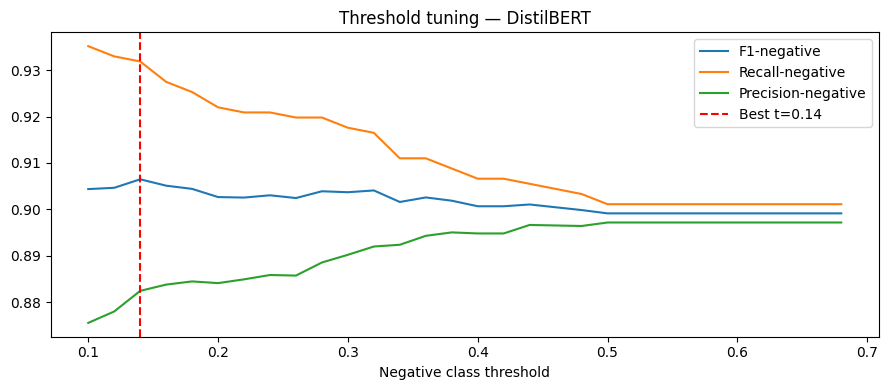

In [19]:
# Replace with whichever trainer won on val_f1_negative in MLflow
# best_trainer = weighted_trainer   # update after reviewing MLflow

# Softmax probabilities on the val set
val_logits = best_trainer.predict(val_ds).predictions
val_probs = torch.softmax(torch.tensor(val_logits), dim=-1).numpy()
val_probs_neg = val_probs[:, NEG_IDX]
val_base_preds = np.argmax(val_probs, axis=-1)

thresholds = np.arange(0.10, 0.70, 0.02)
results = []
for t in thresholds:
    preds = np.where(val_probs_neg >= t, NEG_IDX, val_base_preds)
    results.append({
        "threshold":          t,
        "f1_negative":        f1_score(y_val, preds, labels=[NEG_IDX], average="macro"),
        "recall_negative":    recall_score(y_val, preds, labels=[NEG_IDX], average="macro"),
        "precision_negative": precision_score(y_val, preds, labels=[NEG_IDX], average="macro"),
    })

results_df = pd.DataFrame(results)
best_threshold = results_df.loc[results_df.f1_negative.idxmax(), "threshold"]
print(f"Best threshold: {best_threshold:.2f}")

plt.figure(figsize=(9, 4))
plt.plot(results_df.threshold, results_df.f1_negative,        label="F1-negative")
plt.plot(results_df.threshold, results_df.recall_negative,    label="Recall-negative")
plt.plot(results_df.threshold, results_df.precision_negative, label="Precision-negative")
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best t={best_threshold:.2f}")
plt.xlabel("Negative class threshold")
plt.legend()
plt.title("Threshold tuning — DistilBERT")
plt.tight_layout()
threshold_plot_path = ROOT / "notebooks" / "distilbert_threshold_curve.png"
plt.savefig(threshold_plot_path)
plt.show()

## [7] Final evaluation on test + OOT

Best trainer + best threshold. These numbers go in the report and into the
baseline-vs-DistilBERT comparison.

In [20]:
def predict_distilbert_with_threshold(trainer, dataset, threshold):
    logits = trainer.predict(dataset).predictions
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    base_pred = np.argmax(probs, axis=-1)
    return np.where(probs[:, NEG_IDX] >= threshold, NEG_IDX, base_pred)


with mlflow.start_run(run_name="distilbert-final"):
    mlflow.log_params({"neg_threshold": best_threshold})
    mlflow.log_artifact(str(threshold_plot_path))

    evaluate(y_test, predict_distilbert_with_threshold(best_trainer, test_ds, best_threshold), "test")
    evaluate(y_oot,  predict_distilbert_with_threshold(best_trainer, oot_ds,  best_threshold), "oot")

    final_run_id = mlflow.active_run().info.run_id

100%|██████████| 135/135 [00:37<00:00,  3.57it/s]



── TEST ──
              precision    recall  f1-score   support

    negative       0.88      0.93      0.90       911
     neutral       0.53      0.47      0.50       309
    positive       0.97      0.97      0.97      3082

    accuracy                           0.92      4302
   macro avg       0.79      0.79      0.79      4302
weighted avg       0.92      0.92      0.92      4302



100%|██████████| 161/161 [00:45<00:00,  3.57it/s]


── OOT ──
              precision    recall  f1-score   support

    negative       0.86      0.92      0.89      1119
     neutral       0.55      0.45      0.49       407
    positive       0.97      0.97      0.97      3621

    accuracy                           0.92      5147
   macro avg       0.79      0.78      0.78      5147
weighted avg       0.91      0.92      0.91      5147



## [8] Register best model to MLflow

Saves model + tokenizer to one directory (so the API can rehydrate both) and registers as
**`sentiment-distilbert`**. Promote to `Staging` manually in the MLflow UI before the
FastAPI shadow deploy can load it.

In [22]:
best_dir = ARTIFACT_DIR / "distilbert_best"
best_trainer.save_model(str(best_dir))
tokenizer.save_pretrained(str(best_dir))
print(f"Saved model + tokenizer: {best_dir}")

with mlflow.start_run(run_id=final_run_id):
    mlflow.transformers.log_model(
        transformers_model={"model": best_trainer.model, "tokenizer": tokenizer},
        artifact_path="model",
        registered_model_name="sentiment-distilbert",
        task="text-classification",
    )
print("Registered: sentiment-distilbert")


Saved model + tokenizer: c:\SMU_MITB\MLE\CS611_MLE\social_listener_project\Machine-Learning-Engineering-Group-9-Social-Listener\models\artifacts\distilbert_best


  0%|          | 0/9988 [6:28:48<?, ?it/s]
2026/06/13 20:57:50 WARNING mlflow.transformers: The model card could not be retrieved from the hub due to Repo id must use alphanumeric chars, '-', '_' or '.'. The name cannot start or end with '-' or '.' and the maximum length is 96: 'c:\SMU_MITB\MLE\CS611_MLE\social_listener_project\Machine-Learning-Engineering-Group-9-Social-Listener\checkpoints\distilbert-sentiment/distilbert-baseline\checkpoint-8604'.
2026/06/13 20:57:50 WARNING mlflow.transformers: Unable to find license information for this model. Please verify permissible usage for the model you are storing prior to use.
2026/06/13 20:57:50 WARNING mlflow.utils.requirements_utils: Found torch version (2.12.0+cu132) contains a local version label (+cu132). MLflow logged a pip requirement for this package as 'torch==2.12.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_require

Registered: sentiment-distilbert


Created version '1' of model 'sentiment-distilbert'.


## [9] LR sensitivity experiment (optional, recommended for the report)

Three single-epoch probes to find the best learning rate before committing to full
training. Each probe is logged to MLflow as `distilbert-lr-probe-{lr}`.

In [23]:
for lr in [5e-6, 2e-5, 5e-5]:
    args = get_training_args(f"distilbert-lr-{lr}")
    args.num_train_epochs = 1   # probe only
    args.learning_rate = lr

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_CHECKPOINT, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID
    )
    trainer = WeightedLossTrainer(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=val_ds,
        compute_metrics=compute_hf_metrics,
    )
    with mlflow.start_run(run_name=f"distilbert-lr-probe-{lr}"):
        mlflow.log_param("lr", lr)
        trainer.train()
        val_preds = np.argmax(trainer.predict(val_ds).predictions, axis=-1)
        evaluate(y_val, val_preds, "val")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
 23%|██▎       | 500/2151 [05:11<17:33,  1.57it/s]

{'loss': 0.8199, 'grad_norm': 12.060062408447266, 'learning_rate': 4.271317829457365e-06, 'epoch': 0.23}


 46%|████▋     | 1000/2151 [10:24<12:07,  1.58it/s]

{'loss': 0.5098, 'grad_norm': 19.763486862182617, 'learning_rate': 2.9819121447028427e-06, 'epoch': 0.46}


 70%|██████▉   | 1500/2151 [15:35<06:45,  1.60it/s]

...

{'eval_loss': 0.45174646377563477, 'eval_f1_negative': 0.8893805309734514, 'eval_f1_macro': 0.7903161082001099, 'eval_runtime': 31.5738, 'eval_samples_per_second': 136.252, 'eval_steps_per_second': 4.276, 'epoch': 1.0}


100%|██████████| 2151/2151 [18:47<00:00,  1.91it/s]


{'train_runtime': 1127.3016, 'train_samples_per_second': 30.527, 'train_steps_per_second': 1.908, 'train_loss': 0.5433000026332229, 'epoch': 1.0}


100%|██████████| 135/135 [00:30<00:00,  4.37it/s]


── VAL ──
              precision    recall  f1-score   support

    negative       0.90      0.88      0.89       910
     neutral       0.44      0.63      0.52       310
    positive       0.98      0.94      0.96      3082

    accuracy                           0.91      4302
   macro avg       0.77      0.82      0.79      4302
weighted avg       0.92      0.91      0.91      4302



## Model selection rule (from the instructions)

Pick the run with the highest **`test_f1_negative`** across both notebooks.
If two runs are within 0.01 of each other, prefer the **simpler** model
(logreg over distilbert; no sampling over sampling).

Registered names: `sentiment-baseline` (notebook 01), `sentiment-distilbert` (this notebook).
Both must be promoted to `Staging` in the MLflow UI before the FastAPI shadow deploy
can load them.